# Projet Smart Grid — Analyse Exploratoire des Données (EDA)
### London Smart Meters — Étape 1 du projet

Groupe Jour 2 — Équipe 1 : Alpha Mamadou Douah BARRY, Khalilou Yacouba TANDIA, Ndeye Sophie MBAYE, Issiaka TRAORE


## 0. Setup et chargement des données

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
RANDOM_STATE = 42


In [3]:
HHBLOCK_DIR = "data/hhblock_dataset/hhblock_dataset"

block_files = sorted([f for f in os.listdir(HHBLOCK_DIR) if f.endswith(".csv")])
print(f"{len(block_files)} fichiers block_*.csv trouvés")

dfs = [pd.read_csv(os.path.join(HHBLOCK_DIR, f)) for f in block_files]
df_hh = pd.concat(dfs, ignore_index=True)

df_hh["day"] = pd.to_datetime(df_hh["day"])
hh_cols = [f"hh_{i}" for i in range(48)]

print("Shape :", df_hh.shape)
print("Période :", df_hh["day"].min(), "->", df_hh["day"].max())
print("Foyers uniques :", df_hh["LCLid"].nunique())
df_hh.head()


112 fichiers block_*.csv trouvés
Shape : (3469352, 50)
Période : 2011-11-24 00:00:00 -> 2014-02-27 00:00:00
Foyers uniques : 5560


,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256


In [4]:
df_info = pd.read_csv("data/informations_households.csv")
df_weather = pd.read_csv("data/weather_daily_darksky.csv")
df_bh = pd.read_csv("data/uk_bank_holidays.csv")

df_weather["time"] = pd.to_datetime(df_weather["time"])
df_bh["Bank holidays"] = pd.to_datetime(df_bh["Bank holidays"])

print(df_info.shape, df_weather.shape, df_bh.shape)


(5566, 5) (882, 32) (25, 2)


## 1. Volumétrie, qualité et carte des valeurs manquantes

In [5]:
# Nombre de jours DISTINCTS par foyer et par mois
df_hh["year_month"] = df_hh["day"].dt.to_period("M")
jours_par_foyer_mois = df_hh.groupby(["LCLid", "year_month"])["day"].nunique().unstack(fill_value=0)

print("Shape (foyers x mois) :", jours_par_foyer_mois.shape)
jours_par_foyer_mois.head()


Shape (foyers x mois) : (5560, 28)


year_month,2011-11,2011-12,2012-01,2012-02,2012-03,2012-04,2012-05,2012-06,2012-07,2012-08,...,2013-05,2013-06,2013-07,2013-08,2013-09,2013-10,2013-11,2013-12,2014-01,2014-02
LCLid,,,,,,,,,,,,,,,,,,,,,
MAC000002,0,0,0,0,0,0,0,0,0,0,...,31,30,31,31,30,31,30,31,30,27
MAC000003,0,0,0,9,31,30,30,30,31,31,...,30,30,31,31,30,31,30,31,31,27
MAC000004,0,0,0,0,0,0,23,28,31,31,...,30,30,31,31,30,31,30,31,31,27
MAC000005,0,0,0,0,0,0,0,27,30,31,...,31,30,31,31,30,31,30,31,31,27
MAC000006,0,0,1,29,31,30,30,30,31,31,...,31,30,31,31,30,31,30,31,31,27


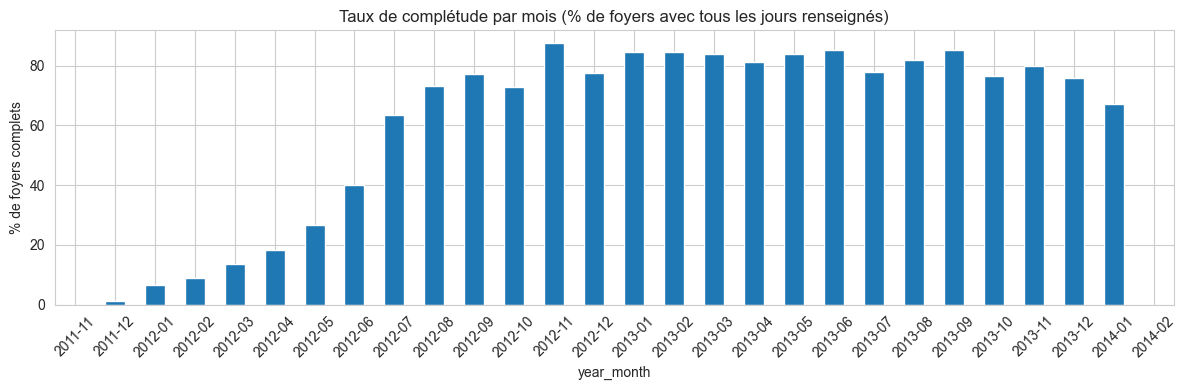

In [6]:
# Taux de complétude par mois : nombre attendu de jours dans chaque mois
nb_jours_calendaire = {col: col.days_in_month for col in jours_par_foyer_mois.columns}

taux_completude = jours_par_foyer_mois.copy()
for col in taux_completude.columns:
    taux_completude[col] = taux_completude[col] / nb_jours_calendaire[col]

completude_moyenne_par_mois = (taux_completude == 1.0).mean() * 100

plt.figure(figsize=(12, 4))
completude_moyenne_par_mois.plot(kind="bar")
plt.ylabel("% de foyers complets")
plt.title("Taux de complétude par mois (% de foyers avec tous les jours renseignés)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


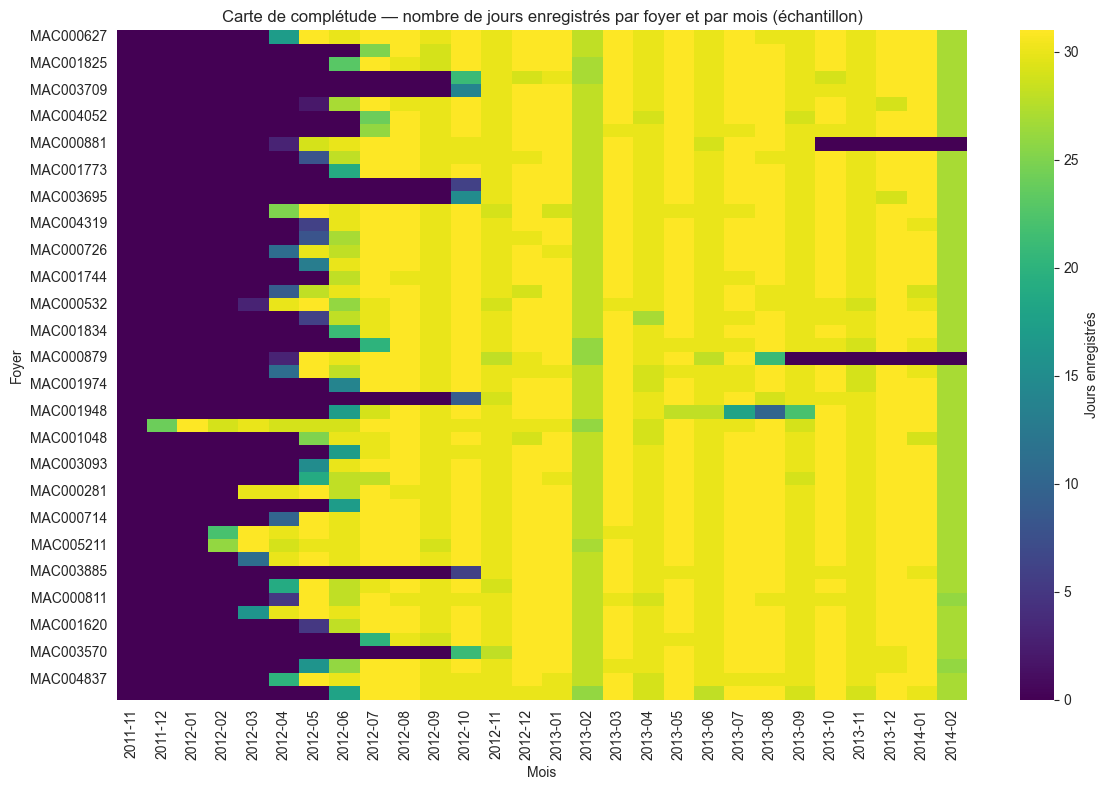

In [7]:
# Carte des valeurs manquantes : heatmap foyers x mois (échantillon de 50 foyers pour la lisibilité)
plt.figure(figsize=(12, 8))
echantillon = jours_par_foyer_mois.sample(min(50, jours_par_foyer_mois.shape[0]), random_state=RANDOM_STATE)
sns.heatmap(echantillon, cmap="viridis", cbar_kws={"label": "Jours enregistrés"})
plt.title("Carte de complétude — nombre de jours enregistrés par foyer et par mois (échantillon)")
plt.xlabel("Mois")
plt.ylabel("Foyer")
plt.tight_layout()
plt.show()


In [8]:
# Résumé chiffré global
print(f"Nombre total de foyers : {df_hh['LCLid'].nunique()}")
print(f"Nombre de mois couverts : {df_hh['year_month'].nunique()}")
print(f"Nombre total de lignes (foyer x jour) : {df_hh.shape[0]}")

# Valeurs manquantes et aberrantes dans les 48 colonnes horaires
print(f"\nValeurs manquantes (NaN) dans hh_0..hh_47 : {df_hh[hh_cols].isna().sum().sum()}")
print(f"Valeurs négatives : {(df_hh[hh_cols] < 0).sum().sum()}")


Nombre total de foyers : 5560
Nombre de mois couverts : 28
Nombre total de lignes (foyer x jour) : 3469352

Valeurs manquantes (NaN) dans hh_0..hh_47 : 5486
Valeurs négatives : 0


In [9]:
import gc

# On supprime les gros objets intermédiaires qui ne servent plus à cette étape
# (garde uniquement df_hh, hh_cols, df_info, df_weather, df_bh dont on a encore besoin)
for var_name in ["jours_par_foyer_mois", "taux_completude", "echantillon"]:
    if var_name in dir():
        del globals()[var_name]

# gc.collect() force Python à libérer immédiatement la mémoire des objets supprimés
gc.collect()

14697

## 2. Distributions et valeurs aberrantes

Taille de l'échantillon : 2,400,000 valeurs


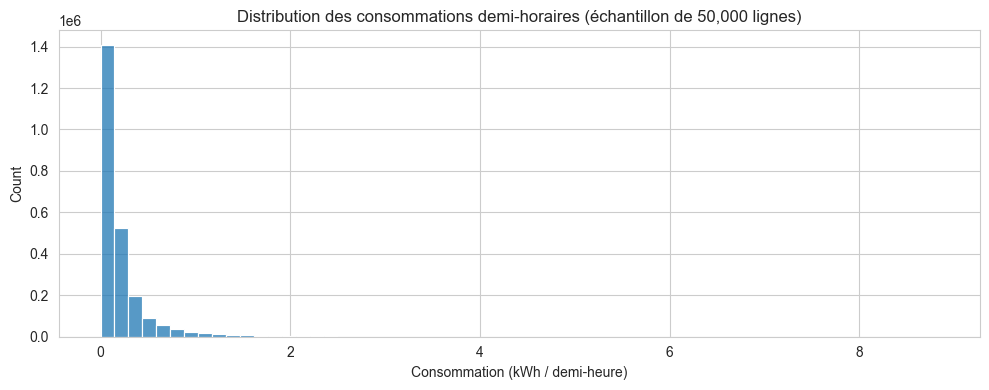

5951

In [10]:
# On réduit franchement la taille de l'échantillon (50 000 suffit largement
# pour un histogramme représentatif, et pèse ~20 Mo au lieu de plusieurs Go)
n_lignes_echantillon = min(50_000, df_hh.shape[0])

# np.random.choice sur des POSITIONS ENTIÈRES (pas le vrai index pandas) :
# beaucoup plus léger, ça ne manipule qu'un tableau d'entiers
rng = np.random.default_rng(RANDOM_STATE)
positions = rng.choice(df_hh.shape[0], size=n_lignes_echantillon, replace=False)

# .sort() : trier les positions améliore la performance de la sélection (accès mémoire séquentiel)
positions.sort()

# .iloc[positions] sélectionne D'ABORD les lignes (positionnel, rapide),
# PUIS [hh_cols] sélectionne les colonnes seulement sur ce petit sous-ensemble
echantillon_hist = df_hh.iloc[positions][hh_cols].to_numpy().flatten()

print(f"Taille de l'échantillon : {echantillon_hist.shape[0]:,} valeurs")

plt.figure(figsize=(10, 4))
sns.histplot(echantillon_hist, bins=60)
plt.xlabel("Consommation (kWh / demi-heure)")
plt.title(f"Distribution des consommations demi-horaires (échantillon de {n_lignes_echantillon:,} lignes)")
plt.tight_layout()
plt.show()

# On libère l'échantillon une fois le graphique tracé
del echantillon_hist
gc.collect()

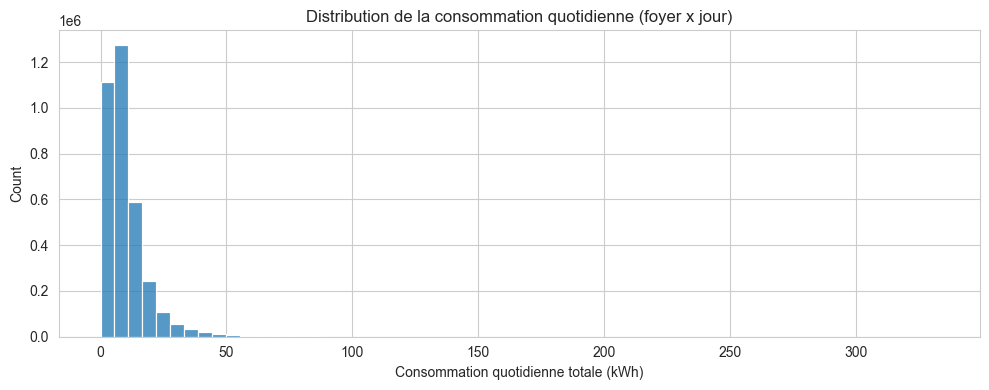

In [11]:
# Consommation QUOTIDIENNE totale par foyer x jour (somme des 48 valeurs)
df_hh["conso_jour"] = df_hh[hh_cols].sum(axis=1)

plt.figure(figsize=(10, 4))
sns.histplot(df_hh["conso_jour"], bins=60)
plt.xlabel("Consommation quotidienne totale (kWh)")
plt.title("Distribution de la consommation quotidienne (foyer x jour)")
plt.tight_layout()
plt.show()


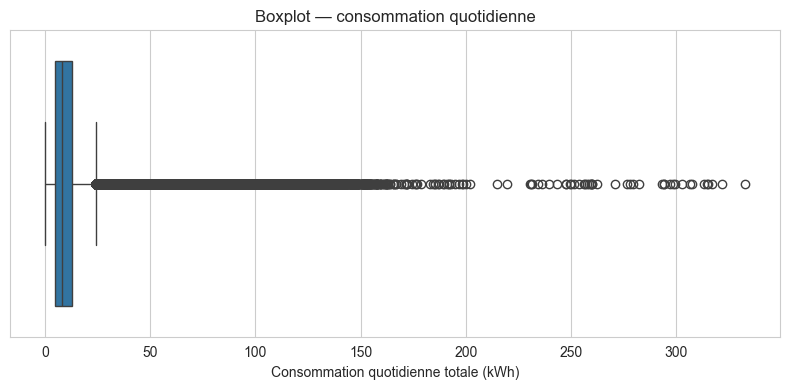

In [12]:
# Boxplot pour repérer les valeurs aberrantes
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_hh["conso_jour"])
plt.xlabel("Consommation quotidienne totale (kWh)")
plt.title("Boxplot — consommation quotidienne")
plt.tight_layout()
plt.show()


In [13]:
# Détection des outliers par la méthode IQR (interquartile range)
q1 = df_hh["conso_jour"].quantile(0.25)
q3 = df_hh["conso_jour"].quantile(0.75)
iqr = q3 - q1
borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr

outliers = df_hh[(df_hh["conso_jour"] < borne_basse) | (df_hh["conso_jour"] > borne_haute)]

print(f"Bornes IQR : [{borne_basse:.2f}, {borne_haute:.2f}] kWh")
print(f"Nombre de jours-foyers aberrants : {outliers.shape[0]} ({100*outliers.shape[0]/df_hh.shape[0]:.2f}%)")


Bornes IQR : [-7.11, 24.43] kWh
Nombre de jours-foyers aberrants : 199636 (5.75%)


In [14]:
print(df_hh["conso_jour"].describe())
print("\nQuantiles élevés :")
print(df_hh["conso_jour"].quantile([0.95, 0.99, 0.999, 0.9999]))

count    3.469352e+06
mean     1.016436e+01
std      9.130546e+00
min      0.000000e+00
25%      4.715000e+00
50%      7.844000e+00
75%      1.260100e+01
max      3.325560e+02
Name: conso_jour, dtype: float64

Quantiles élevés :
0.9500     25.828000
0.9900     45.842490
0.9990     87.200649
0.9999    134.460582
Name: conso_jour, dtype: float64


In [15]:
for seuil in [50, 75, 100, 150, 200]:
    nb = (df_hh["conso_jour"] > seuil).sum()
    pct = 100 * nb / df_hh.shape[0]
    print(f"> {seuil} kWh/jour : {nb} lignes ({pct:.3f}%)")

> 50 kWh/jour : 26310 lignes (0.758%)
> 75 kWh/jour : 6399 lignes (0.184%)
> 100 kWh/jour : 1972 lignes (0.057%)
> 150 kWh/jour : 152 lignes (0.004%)
> 200 kWh/jour : 45 lignes (0.001%)


Foyer : MAC003394, Jour : 2013-11-24 00:00:00, Total : 166.8 kWh


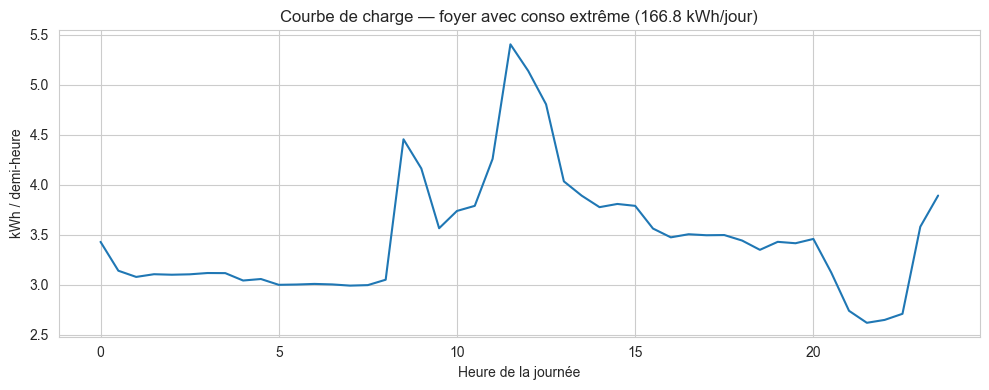

In [17]:
exemple_extreme = df_hh[df_hh["conso_jour"] > 150].iloc[0] if (df_hh["conso_jour"] > 150).any() else None
heures = np.arange(48) / 2
if exemple_extreme is not None:
    print(f"Foyer : {exemple_extreme['LCLid']}, Jour : {exemple_extreme['day']}, Total : {exemple_extreme['conso_jour']:.1f} kWh")
    plt.figure(figsize=(10, 4))
    plt.plot(heures, exemple_extreme[hh_cols].values.astype(float))
    plt.xlabel("Heure de la journée")
    plt.ylabel("kWh / demi-heure")
    plt.title(f"Courbe de charge — foyer avec conso extrême ({exemple_extreme['conso_jour']:.1f} kWh/jour)")
    plt.tight_layout()
    plt.show()
else:
    print("Aucun foyer au-dessus de 150 kWh/jour")

## Traitement des valeurs extrêmes

L'analyse par la méthode IQR classique détecte 5.75% de "valeurs aberrantes" sur la consommation quotidienne, mais ce chiffre est trompeur : cette règle statistique générique est mal adaptée à une distribution naturellement asymétrique comme celle-ci. En creusant par seuils, les vraies valeurs extrêmes sont en réalité très rares (0.057% au-delà de 100 kWh/jour, 0.001% au-delà de 200 kWh/jour). L'inspection d'un cas extrême (166.8 kWh/jour) montre une consommation élevée mais cohérente sur 24h, plutôt qu'un pic isolé lié à une erreur de capteur — signe d'un comportement réel (possible usage non-résidentiel), pas d'une donnée corrompue.

**Décision retenue** : aucune exclusion de foyers ou de mesures. Ces cas restent trop marginaux en volume pour justifier un filtrage, et la normalisation par ligne qui est demandé dans le clustering (Approche B) neutralise déjà l'effet du volume en comparant les foyers sur la forme de leur courbe plutôt que sur leur niveau de consommation absolu. Le dataset est donc conservé intact pour la suite du projet.

## 3. Courbes de charge moyennes — globale, par jour de semaine, par mois

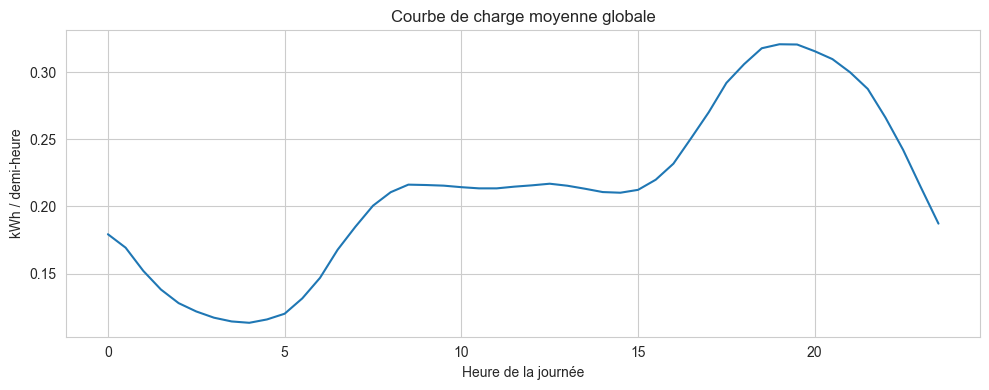

In [15]:
# Courbe moyenne GLOBALE (toutes mesures, tous foyers, toute la période)
courbe_globale = df_hh[hh_cols].mean()
heures = np.arange(48) / 2

plt.figure(figsize=(10, 4))
plt.plot(heures, courbe_globale.values)
plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne globale")
plt.tight_layout()
plt.show()


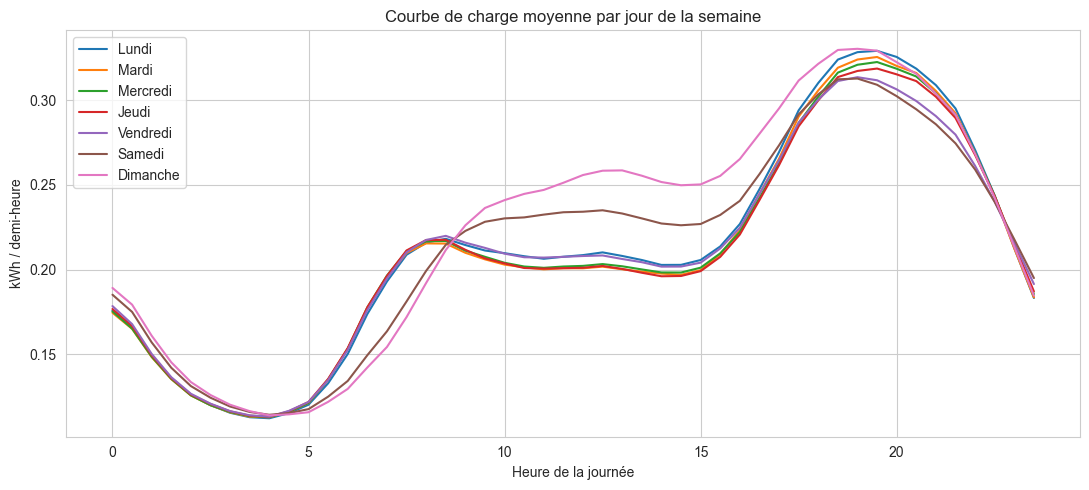

In [16]:
# Courbe moyenne par jour de la semaine (0=lundi ... 6=dimanche)
df_hh["jour_semaine"] = df_hh["day"].dt.dayofweek
courbes_par_jour = df_hh.groupby("jour_semaine")[hh_cols].mean()

noms_jours = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

plt.figure(figsize=(11, 5))
for j in range(7):
    plt.plot(heures, courbes_par_jour.loc[j], label=noms_jours[j])
plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne par jour de la semaine")
plt.legend()
plt.tight_layout()
plt.show()


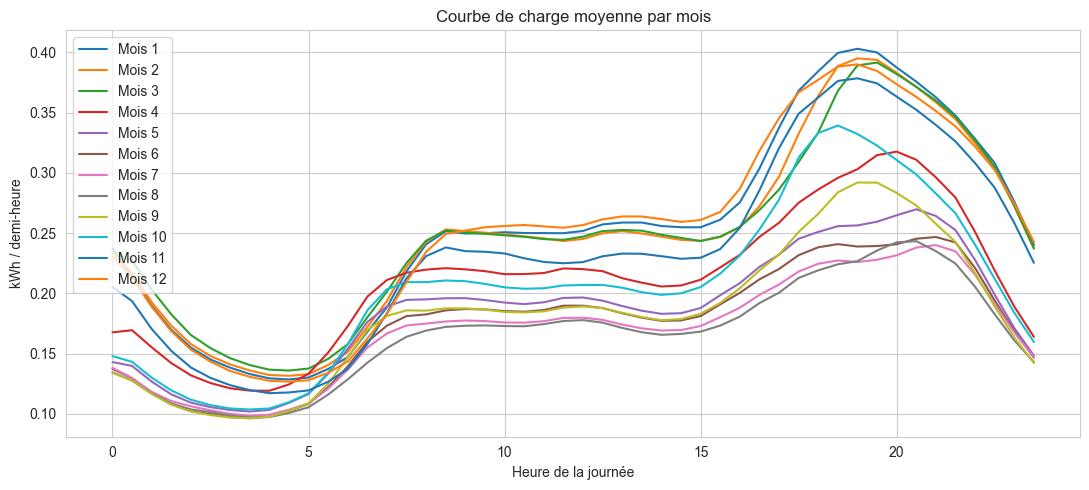

In [17]:
# Courbe moyenne par mois
df_hh["mois"] = df_hh["day"].dt.month
courbes_par_mois = df_hh.groupby("mois")[hh_cols].mean()

plt.figure(figsize=(11, 5))
for m in sorted(df_hh["mois"].unique()):
    plt.plot(heures, courbes_par_mois.loc[m], label=f"Mois {m}")
plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne par mois")
plt.legend()
plt.tight_layout()
plt.show()


## Conclusion — forme de la courbe et effet saison

La courbe de charge moyenne montre un plateau de journée suivi d'une pointe unique et dominante en soirée (18h-20h), plutôt qu'une double pointe matin/soir nettement séparée. L'effet saison est en revanche très marqué : les mois d'hiver (nov-jan) culminent à ~0.38-0.40 kWh contre ~0.27-0.30 kWh pour les mois d'été, confirmant l'impact du chauffage électrique.

## 4. Effet météo — corrélation conso / température

In [18]:
# Température moyenne quotidienne (moyenne de max et min)
df_weather["day_norm"] = df_weather["time"].dt.normalize()
df_weather["temp_moyenne"] = (df_weather["temperatureMax"] + df_weather["temperatureMin"]) / 2
df_weather_small = df_weather[["day_norm", "temp_moyenne"]]

df_hh["day_norm"] = df_hh["day"].dt.normalize()
merged_meteo = df_hh.merge(df_weather_small, on="day_norm", how="left")

print("Lignes sans température après jointure :", merged_meteo["temp_moyenne"].isna().sum())


Lignes sans température après jointure : 10678


Corrélation globale conso-température : -0.173


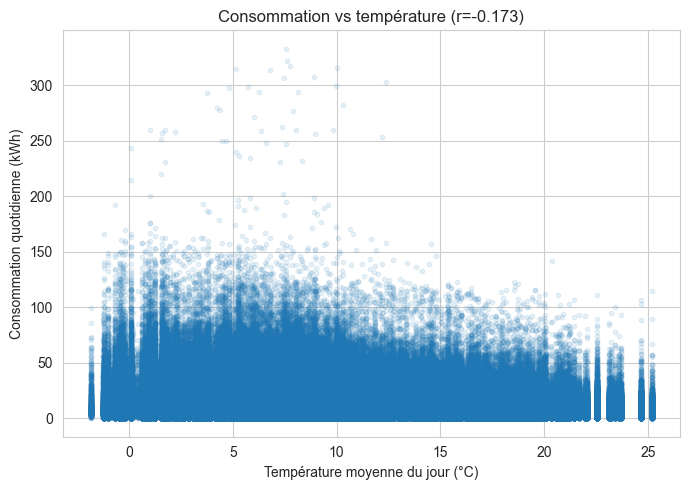

In [19]:
# Corrélation GLOBALE conso quotidienne / température
correlation_globale = merged_meteo["conso_jour"].corr(merged_meteo["temp_moyenne"])
print(f"Corrélation globale conso-température : {correlation_globale:.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(merged_meteo["temp_moyenne"], merged_meteo["conso_jour"], alpha=0.1, s=10)
plt.xlabel("Température moyenne du jour (°C)")
plt.ylabel("Consommation quotidienne (kWh)")
plt.title(f"Consommation vs température (r={correlation_globale:.3f})")
plt.tight_layout()
plt.show()


In [20]:
# Corrélation conso-température PAR FOYER (identifie les foyers "chauffage électrique")
def correlation_conso_temp(groupe):
    return groupe["conso_jour"].corr(groupe["temp_moyenne"])

correlations_par_foyer = merged_meteo.groupby("LCLid").apply(correlation_conso_temp)

print(correlations_par_foyer.describe())


c:\Users\douah\projet_ml_unsupervised\venv-ml\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\douah\projet_ml_unsupervised\venv-ml\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


count    5559.000000
mean       -0.300008
std         0.250914
min        -0.939287
25%        -0.464556
50%        -0.302296
75%        -0.147307
max         0.787094
dtype: float64


C:\Users\douah\AppData\Local\Temp\ipykernel_43500\2390729702.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations_par_foyer = merged_meteo.groupby("LCLid").apply(correlation_conso_temp)


Foyers avec forte anti-corrélation température (r < -0.3) : 2808
Soit 50.5% des foyers


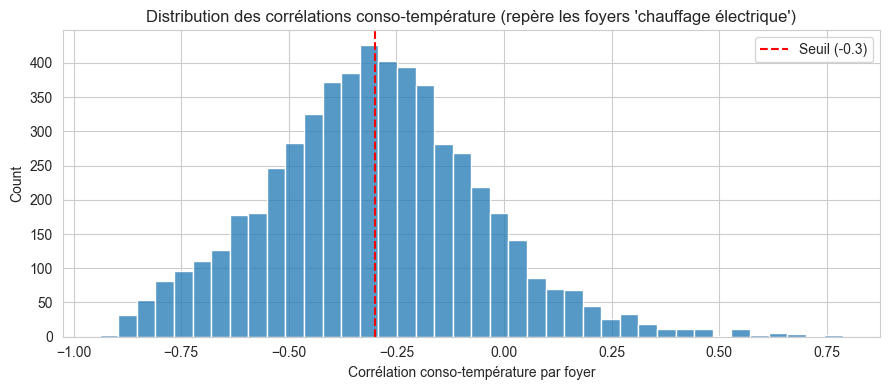

In [21]:
# On identifie les foyers avec une anti-corrélation marquée (conso monte quand temp baisse)
SEUIL_CHAUFFAGE = -0.3
foyers_chauffage = correlations_par_foyer[correlations_par_foyer < SEUIL_CHAUFFAGE]

print(f"Foyers avec forte anti-corrélation température (r < {SEUIL_CHAUFFAGE}) : {len(foyers_chauffage)}")
print(f"Soit {100*len(foyers_chauffage)/len(correlations_par_foyer):.1f}% des foyers")

plt.figure(figsize=(9, 4))
sns.histplot(correlations_par_foyer, bins=40)
plt.axvline(SEUIL_CHAUFFAGE, color="red", linestyle="--", label=f"Seuil ({SEUIL_CHAUFFAGE})")
plt.xlabel("Corrélation conso-température par foyer")
plt.title("Distribution des corrélations conso-température (repère les foyers 'chauffage électrique')")
plt.legend()
plt.tight_layout()
plt.show()


## Conclusion — effet météo

Plus de la moitié des foyers (50.5%) présentent une anti-corrélation marquée entre consommation quotidienne et température (r < -0.3), confirmant que le chauffage électrique est un facteur déterminant de la consommation résidentielle londonienne. La distribution des corrélations est centrée autour de -0.3/-0.4, avec une minorité de foyers (traîne à droite) montrant une relation positive ou nulle avec la météo — probablement des foyers sans chauffage électrique ou avec un profil de consommation dominé par d'autres usages.

## 5. Effet calendrier — semaine / week-end / jours fériés

In [22]:
# Classification de chaque jour : semaine, week-end, ou férié (le férié est prioritaire)
jours_feries = set(df_bh["Bank holidays"])

df_hh["type_jour"] = "Semaine"
df_hh.loc[df_hh["jour_semaine"] >= 5, "type_jour"] = "Week-end"
df_hh.loc[df_hh["day_norm"].isin(jours_feries), "type_jour"] = "Férié"

print(df_hh["type_jour"].value_counts())


type_jour
Semaine     2401297
Week-end     987974
Férié         80081
Name: count, dtype: int64


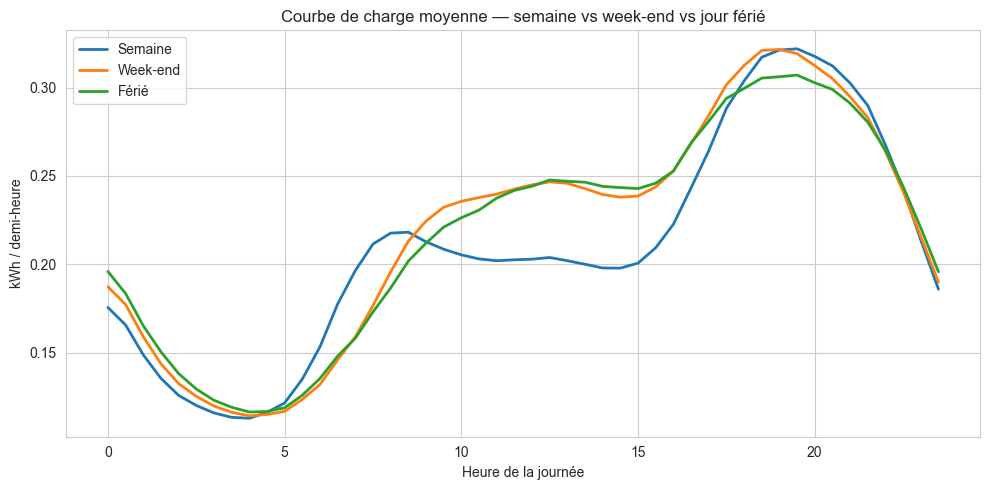

In [23]:
# Courbe moyenne par type de jour
courbes_par_type = df_hh.groupby("type_jour")[hh_cols].mean()

plt.figure(figsize=(10, 5))
for type_j in ["Semaine", "Week-end", "Férié"]:
    if type_j in courbes_par_type.index:
        plt.plot(heures, courbes_par_type.loc[type_j], label=type_j, linewidth=2)

plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne — semaine vs week-end vs jour férié")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
# Comparaison chiffrée : volume quotidien moyen par type de jour
volume_par_type = df_hh.groupby("type_jour")["conso_jour"].mean()
print("Volume quotidien moyen par type de jour (kWh) :")
print(volume_par_type.round(2))


Volume quotidien moyen par type de jour (kWh) :
type_jour
Férié       10.43
Semaine     10.02
Week-end    10.49
Name: conso_jour, dtype: float64


## 6. Premier regard ACORN

In [25]:
# Jointure avec les catégories ACORN
merged_acorn = df_hh.merge(df_info[["LCLid", "Acorn_grouped"]], on="LCLid", how="left")

print(merged_acorn["Acorn_grouped"].value_counts())


Acorn_grouped
Affluent       1392263
Adversity      1120814
Comfortable     926337
ACORN-U          29167
ACORN-             771
Name: count, dtype: int64


Consommation quotidienne moyenne par catégorie ACORN (kWh) :
Acorn_grouped
ACORN-         12.05
ACORN-U        11.68
Affluent       11.52
Comfortable    10.04
Adversity       8.54
Name: conso_jour, dtype: float64


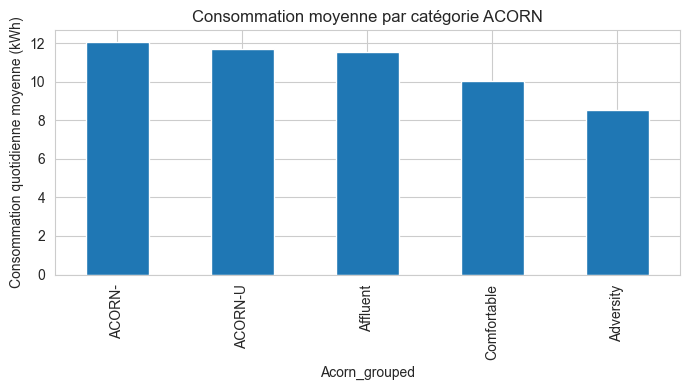

In [26]:
# Consommation quotidienne moyenne par catégorie ACORN
conso_par_acorn = merged_acorn.groupby("Acorn_grouped")["conso_jour"].mean().sort_values(ascending=False)

print("Consommation quotidienne moyenne par catégorie ACORN (kWh) :")
print(conso_par_acorn.round(2))

plt.figure(figsize=(7, 4))
conso_par_acorn.plot(kind="bar")
plt.ylabel("Consommation quotidienne moyenne (kWh)")
plt.title("Consommation moyenne par catégorie ACORN")
plt.tight_layout()
plt.show()


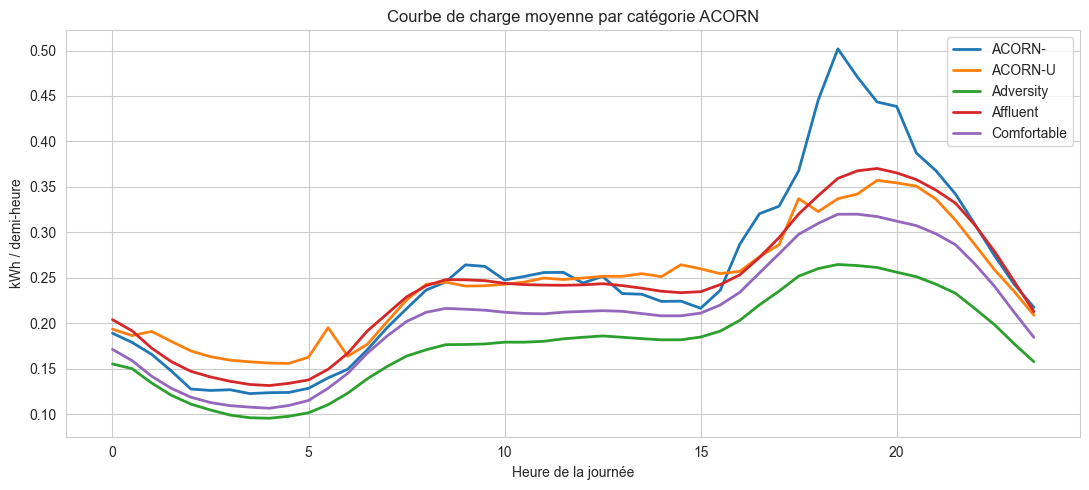

In [27]:
# Courbes de charge moyennes par catégorie ACORN
courbes_par_acorn = merged_acorn.groupby("Acorn_grouped")[hh_cols].mean()

plt.figure(figsize=(11, 5))
for cat in courbes_par_acorn.index:
    plt.plot(heures, courbes_par_acorn.loc[cat], label=cat, linewidth=2)

plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne par catégorie ACORN")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
# Test statistique : la conso quotidienne diffère-t-elle significativement selon Acorn_grouped ?
from scipy.stats import f_oneway

groupes_acorn = [merged_acorn[merged_acorn["Acorn_grouped"] == cat]["conso_jour"].dropna()
                 for cat in merged_acorn["Acorn_grouped"].dropna().unique()]

f_stat, p_value_acorn = f_oneway(*groupes_acorn)
print(f"ANOVA : F={f_stat:.2f}, p-value={p_value_acorn:.4f}")
print("→", "Différence significative" if p_value_acorn < 0.05 else "Pas de différence significative",
      "entre les catégories ACORN (seuil 5%)")


ANOVA : F=17093.53, p-value=0.0000
→ Différence significative entre les catégories ACORN (seuil 5%)


## Synthèse de l'EDA

**Volumétrie et qualité** : 5 560 foyers, 3 469 352 lignes (foyer × jour) sur nov. 2011 → févr. 2014, données quasi propres (5 486 NaN négligeables, 0 valeur négative).

**Distributions** : consommation quotidienne fortement asymétrique (médiane 7.84 kWh, moyenne 10.16 kWh). La règle IQR détecte 5.75% d'"outliers", mais l'analyse par seuils montre que les vraies valeurs extrêmes sont rares (0.057% > 100 kWh/jour) ; l'inspection d'un cas extrême (166.8 kWh/jour) confirme un comportement cohérent sur 24h plutôt qu'une erreur de mesure — aucune exclusion appliquée.

**Courbe de charge** : plateau de journée suivi d'une pointe unique dominante le soir (18h-20h), plutôt qu'une double pointe matin/soir nette. Effet saison marqué (pics hivernaux ~0.38-0.40 kWh contre ~0.27-0.30 kWh en été).

**Effet météo** : corrélation globale conso-température de -0.173 ; 50.5% des foyers (2 808) montrent une anti-corrélation marquée (r < -0.3), signe d'un usage de chauffage électrique répandu.

**Effet calendrier** : volume quotidien quasi stable entre semaine (10.02 kWh), week-end (10.49 kWh) et jours fériés (10.43 kWh) — effet modeste en volume, mais la forme des courbes (à visualiser) diffère probablement plus que le total.

**ACORN** : différence hautement significative entre catégories (ANOVA F=17093.53, p<0.0001) — consommation moyenne décroissante de Affluent (11.52 kWh) à Comfortable (10.04) puis Adversity (8.54 kWh), un gradient socio-économique clair. Les catégories non classifiées (ACORN-/ACORN-U, ~0.86% des lignes) sont à exclure de ce croisement pour ne pas polluer l'interprétation.

Ces éléments confirment un chauffage électrique répandu et un lien socio-économique fort avec le volume de consommation — deux pistes déjà exploitées (ou à exploiter) dans l'interprétation des clusters des Approches A et B.